In [1]:
import numpy as np
import pandas as pd
import math

In [2]:
# import synthetic landscape

data_folder = 'sfield/'

lscape_name_notxt = 'dipplane45_45_posdip_fee30_7_13_17_A_1MCstrongxvyvssB1_dyn'

img_folder = 'sfimgs/' + lscape_name_notxt + '/'

synscape = pd.read_csv(data_folder + lscape_name_notxt + '.txt', sep=' ')
print(synscape.shape)
print(synscape.columns)

(9604, 21)
Index(['x,', 'y,', 'z,', 'sig1,', 'sig2,', 'sig3,', 'S1-x,', 'S1-y,', 'S1-z,',
       'S2-x,', 'S2-y,', 'S2-z,', 'S3-x,', 'S3-y,', 'S3-z,', 'sxx,', 'sxy,',
       'sxz,', 'syy,', 'syz,', 'szz'],
      dtype='object')


In [3]:
# remove commas from column names
synscape.columns = synscape.columns.str.replace(',', '', regex=False)
print(synscape.columns)

Index(['x', 'y', 'z', 'sig1', 'sig2', 'sig3', 'S1-x', 'S1-y', 'S1-z', 'S2-x',
       'S2-y', 'S2-z', 'S3-x', 'S3-y', 'S3-z', 'sxx', 'sxy', 'sxz', 'syy',
       'syz', 'szz'],
      dtype='object')


In [4]:
# inspect
print(synscape.shape)
print(synscape.dtypes)
print(synscape[['sig1','sig2','sig3']].describe())
print(synscape[['S1-x','S1-y','S1-z',
                'S2-x','S2-y','S3-z',
                'S3-x','S3-y','S3-z']].describe())

(9604, 21)
x       float64
y       float64
z       float64
sig1    float64
sig2    float64
sig3    float64
S1-x    float64
S1-y    float64
S1-z    float64
S2-x    float64
S2-y    float64
S2-z    float64
S3-x    float64
S3-y    float64
S3-z    float64
sxx     float64
sxy     float64
sxz     float64
syy     float64
syz     float64
szz     float64
dtype: object
               sig1          sig2          sig3
count  9.604000e+03  9.604000e+03  9.604000e+03
mean  -6.929857e+07 -6.266989e+07 -5.724428e+07
std    1.625145e+08  1.577190e+08  1.560333e+08
min   -2.063550e+09 -2.041800e+09 -2.039470e+09
25%   -4.074410e+07 -3.000928e+07 -1.826105e+07
50%   -9.059570e+06 -5.211695e+06 -6.326970e+05
75%   -3.723760e+06 -1.647910e+06 -1.725492e+04
max    2.838440e+05  1.120830e+06  3.693900e+07
              S1-x         S1-y         S1-z         S2-x         S2-y  \
count  9604.000000  9604.000000  9604.000000  9604.000000  9604.000000   
mean      0.335664     0.255394     0.250981     0.274126  

In [5]:
# compare calculated eigenvalues and vectors to dataframe components

# a few test rows (each row is a single element -- not gridded yet)
test_idx = [0, 100, 500]

for idx in test_idx:
    row = synscape.iloc[idx]

    # reconstruct stress tensor from components
    sigma = np.array([
        [row['sxx'], row['sxy'], row['sxz']],
        [row['sxy'], row['syy'], row['syz']],
        [row['sxz'], row['syz'], row['szz']]
    ])

    # eigendecomposition
    eigenvalues, eigenvectors = np.linalg.eigh(sigma)
    # eigh returns ascending order -- reverse to match sig1 >= sig2 >= sig3
    eigenvalues = eigenvalues[::-1]
    eigenvectors = eigenvectors[:,::-1]

    print(f"\nrow {idx}:")
    print(f"  sig1,2,3 from data: {row['sig1']:.4f}, {row['sig2']:.4f}, {row['sig3']:.4f}")
    print(f" eigenvalues derived: {eigenvalues[0]:.4f}, {eigenvalues[1]:.4f}, {eigenvalues[2]:.4f}")
    print(f" S1 from data:   [{row['S1-x']:.4f}, {row['S1-y']:.4f}, {row['S1-z']:.4f}]")
    print(f" S1 derived:     [{eigenvectors[0,0]:.4f}, {eigenvectors[1,0]:.4f}, {eigenvectors[2,0]:.4f}]")


row 0:
  sig1,2,3 from data: -171628000.0000, -170426000.0000, -169744000.0000
 eigenvalues derived: -169744282.0910, -170426227.7696, -171628490.1394
 S1 from data:   [-0.0893, -0.4893, 0.8675]
 S1 derived:     [-0.1000, -0.8622, -0.4965]

row 100:
  sig1,2,3 from data: -164728000.0000, -164442000.0000, -164095000.0000
 eigenvalues derived: -164095247.1369, -164441411.2907, -164727341.5724
 S1 from data:   [-0.4585, 0.8823, -0.1064]
 S1 derived:     [0.2438, 0.2401, 0.9397]

row 500:
  sig1,2,3 from data: -8624010.0000, -3111880.0000, -170066.0000
 eigenvalues derived: -170064.6822, -3111882.6059, -8624012.7119
 S1 from data:   [0.8027, 0.0517, 0.5942]
 S1 derived:     [-0.5802, 0.2989, 0.7577]


In [6]:
# compare calculated eigenvalues and vectors to dataframe components
# new attempt

# a few test rows (each row is a single element -- not gridded yet)
test_idx = [0, 100, 500]

for idx in test_idx:
    row = synscape.iloc[idx]

    # reconstruct stress tensor from components
    sigma = np.array([
        [row['sxx'], row['sxy'], row['sxz']],
        [row['sxy'], row['syy'], row['syz']],
        [row['sxz'], row['syz'], row['szz']]
    ])

    # no reversal -- ascending order matches data convention
    eigenvalues, eigenvectors = np.linalg.eigh(sigma)

    print(f"\nrow {idx}:")
    print(f" eigenvalue match (derived vs data):")
    for k, (ev, sd) in enumerate(zip(eigenvalues,
                                     [row['sig1'],row['sig2'],row['sig3']])):
        print(f"    sig{k+1}: derived={ev:.1f}, data={sd:.1f}, diff={abs(ev-sd):.2f}")

    print(f" eigenvector allignment (|dot product| should be ~1 if same direction):")
    s_data = np.array([[row['S1-x'], row['S1-y'], row['S1-z']],
                        [row['S2-x'], row['S2-y'], row['S2-z']],
                        [row['S3-x'], row['S3-y'], row['S3-z']]])

    for k in range(3):
        dot = abs(np.dot(eigenvectors[:,k], s_data[k]))
        print(f"   S{k+1}: |dot|={dot:.4f}")


row 0:
 eigenvalue match (derived vs data):
    sig1: derived=-171628490.1, data=-171628000.0, diff=490.14
    sig2: derived=-170426227.8, data=-170426000.0, diff=227.77
    sig3: derived=-169744282.1, data=-169744000.0, diff=282.09
 eigenvector allignment (|dot product| should be ~1 if same direction):
   S1: |dot|=1.0000
   S2: |dot|=1.0000
   S3: |dot|=1.0000

row 100:
 eigenvalue match (derived vs data):
    sig1: derived=-164727341.6, data=-164728000.0, diff=658.43
    sig2: derived=-164441411.3, data=-164442000.0, diff=588.71
    sig3: derived=-164095247.1, data=-164095000.0, diff=247.14
 eigenvector allignment (|dot product| should be ~1 if same direction):
   S1: |dot|=1.0000
   S2: |dot|=1.0000
   S3: |dot|=1.0000

row 500:
 eigenvalue match (derived vs data):
    sig1: derived=-8624012.7, data=-8624010.0, diff=2.71
    sig2: derived=-3111882.6, data=-3111880.0, diff=2.61
    sig3: derived=-170064.7, data=-170066.0, diff=1.32
 eigenvector allignment (|dot product| should be ~

In [7]:
# place sxx, ..., syz into grid
# re-derive principals from cubically interpolated grid

In [8]:
from scipy.interpolate import griddata
import numpy as np

# establish grid
x = synscape['x'].values
y = synscape['y'].values

side = int(np.sqrt(len(synscape)))
print(f"side: {side}, side^2: {side**2}, npoints: {len(synscape)}")

side: 98, side^2: 9604, npoints: 9604


In [9]:
x_grid = np.linspace(x.min(), x.max(), side)
y_grid = np.linspace(y.min(), y.max(), side)
xx, yy = np.meshgrid(x_grid, y_grid)
points = synscape[['x','y']].values

# grid z first as sanity check
# grid with cubic first, then fill nans with nearest neighbor
z_cubic = griddata(points, synscape['z'].values, (xx, yy), method='cubic')
z_nearest = griddata(points, synscape['z'].values, (xx, yy), method='nearest')

z_grid = z_cubic.copy()
z_grid[np.isnan(z_cubic)] = z_nearest[np.isnan(z_cubic)]

print(f"z_grid shape: {z_grid.shape}")
print(f"z_grid range: {np.nanmin(z_grid):.2f} to {np.nanmax(z_grid):.2f}")
print(f"z_grid NaNs: {np.isnan(z_grid).sum()}")
print(f"boundary filled: {np.isnan(z_cubic).sum()} points")

z_grid shape: (98, 98)
z_grid range: -267.13 to 963.76
z_grid NaNs: 0
boundary filled: 388 points


In [10]:
print(f"synscape range: {np.nanmin(np.array(synscape['z'])):.2f} to {np.nanmax(np.array(synscape['z'])):.2f}")
print(f"synscape z nans: {np.isnan(synscape['z']).sum()}")

synscape range: -266.46 to 963.76
synscape z nans: 0


In [11]:
# grid six stress tensor components

tensor_components = ['sxx','sxy','sxz','syy','syz','szz']
tensor_grids = {}

for comp in tensor_components:
    cubic = griddata(points, synscape[comp].values, (xx,yy), method='cubic')
    nearest = griddata(points, synscape[comp].values, (xx,yy), method='nearest')
    filled = cubic.copy()
    filled[np.isnan(cubic)] = nearest[np.isnan(cubic)]
    tensor_grids[comp] = filled
    print(f"{comp}: range={filled.min():.4e} to {filled.max():.4e}, NaNs={np.isnan(filled).sum()}")

sxx: range=-1.9849e+09 to 1.4102e+08, NaNs=0
sxy: range=-7.2644e+07 to 1.5775e+08, NaNs=0
sxz: range=-5.6472e+07 to 5.8449e+07, NaNs=0
syy: range=-1.9707e+09 to 1.4540e+08, NaNs=0
syz: range=-4.6858e+07 to 7.6438e+07, NaNs=0
szz: range=-1.9697e+09 to 1.4043e+08, NaNs=0


In [12]:
# eigendecomposition at every point
nrows, ncols = z_grid.shape

# output arrays
sig_grid = np.zeros((nrows, ncols, 3))      # principal stresses
Svec_grid = np.zeros((nrows, ncols, 3, 3))  # principal directions (nrows, ncols, vector, component)

for i in range(nrows):
    for j in range(ncols):
        sigma = np.array([
            [tensor_grids['sxx'][i,j], tensor_grids['sxy'][i,j], tensor_grids['sxz'][i,j]],
            [tensor_grids['sxy'][i,j], tensor_grids['syy'][i,j], tensor_grids['syz'][i,j]],
            [tensor_grids['sxz'][i,j], tensor_grids['syz'][i,j], tensor_grids['szz'][i,j]]
        ])

        eigenvalues, eigenvectors = np.linalg.eigh(sigma)

        # ascending order matches data convention (most compressive first)
        sig_grid[i, j, :] = eigenvalues
        Svec_grid[i, j, :, :] = eigenvectors.T # rows become eigenvectors
        # Svec_grid[i,j,0,:] -- S1 eigenvector (x,y,z components) at point i,j
        # sig_grid[i,j,0] -- sig1 (most compressive) at point (i,j)

print(f"sig_grid shape: {sig_grid.shape}")
print(f"Svec_grid shape: {Svec_grid.shape}")
print(f"sig1 range: {sig_grid[:,:,0].min():.4e} to {sig_grid[:,:,0].max():.4e}")
print(f"sig2 range: {sig_grid[:,:,1].min():.4e} to {sig_grid[:,:,1].max():.4e}")
print(f"sig3 range: {sig_grid[:,:,2].min():.4e} to {sig_grid[:,:,2].max():.4e}")

# spot check unit vector lengths
sample_norms = np.sqrt((Svec_grid[42,42,:,:]**2).sum(axis=1))
print(f"\nspot check eigenvector norms at (42,42): {sample_norms}")

sig_grid shape: (98, 98, 3)
Svec_grid shape: (98, 98, 3, 3)
sig1 range: -1.9937e+09 to 1.3721e+08
sig2 range: -1.9667e+09 to 1.4118e+08
sig3 range: -1.9630e+09 to 1.4847e+08

spot check eigenvector norms at (42,42): [1. 1. 1.]


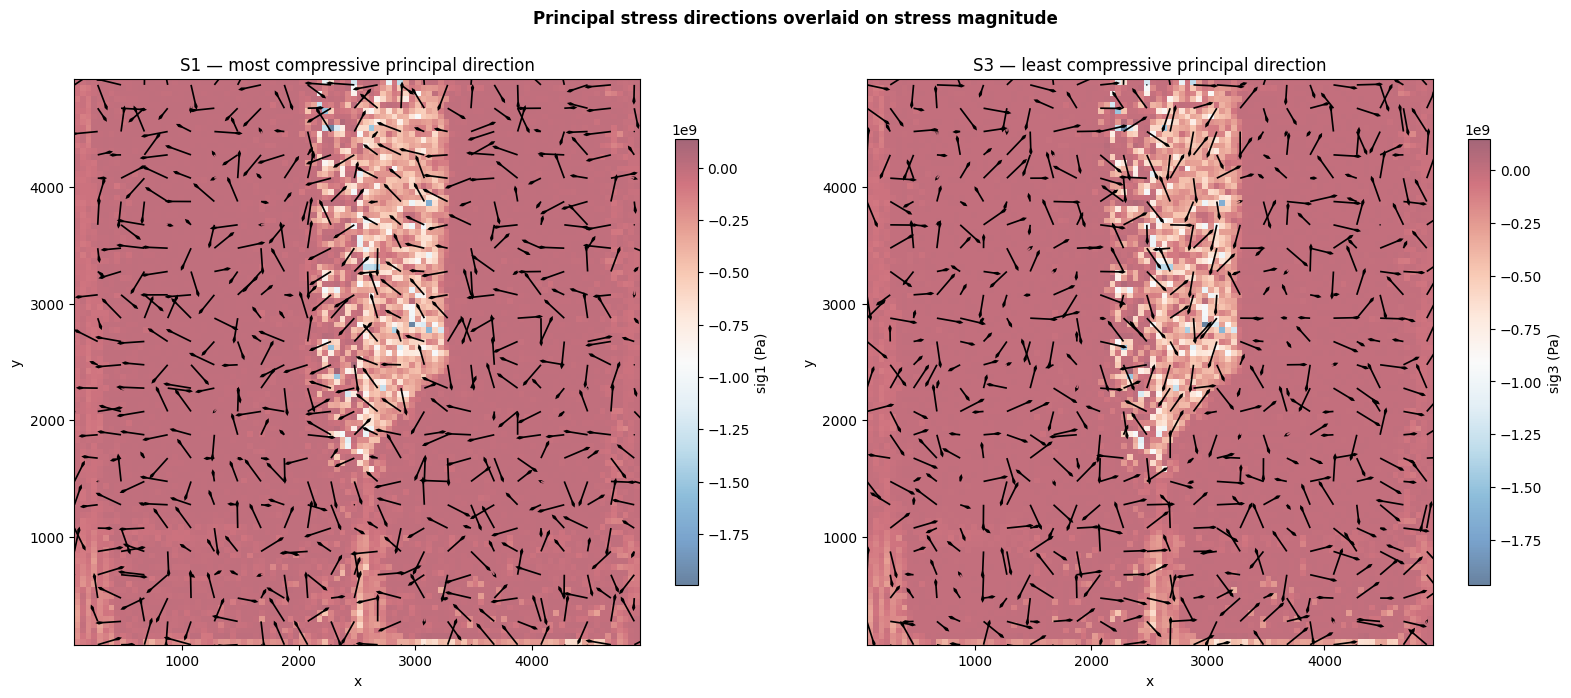

In [13]:
# quiver plot of principal stress directions
# with stress magnitude background

import matplotlib.pyplot as plt

# use every nth point to avoid overcrowding
stride = 4

# extract in-plane components of S1 and S3
# S1 = most compressive, S3 = least compressive
# use x,y components only for the surface plot
S1_x = Svec_grid[::stride, ::stride, 0, 0]  # S1 x-component
S1_y = Svec_grid[::stride, ::stride, 0, 1]  # S1 y-component
S3_x = Svec_grid[::stride, ::stride, 2, 0]  # S3 x-component
S3_y = Svec_grid[::stride, ::stride, 2, 1]  # S3 y-component

# grid coordinates for quiver
x_q = xx[::stride, ::stride]
y_q = yy[::stride, ::stride]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# S1 -- most compressive
im0 = axes[0].imshow(sig_grid[:,:,0], cmap='RdBu_r', origin='lower',
                      extent=[xx.min(), xx.max(), yy.min(), yy.max()],
                      alpha=0.6)
axes[0].quiver(x_q, y_q, S1_x, S1_y,
               color='black', scale=20, width=0.003,
               headwidth=2, headlength=2)
plt.colorbar(im0, ax=axes[0], shrink=0.7, label='sig1 (Pa)')
axes[0].set_title('S1 — most compressive principal direction')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')

# S3 -- least compressive
im1 = axes[1].imshow(sig_grid[:,:,2], cmap='RdBu_r', origin='lower',
                      extent=[xx.min(), xx.max(), yy.min(), yy.max()],
                      alpha=0.6)
axes[1].quiver(x_q, y_q, S3_x, S3_y,
               color='black', scale=20, width=0.003,
               headwidth=2, headlength=2)
plt.colorbar(im1, ax=axes[1], shrink=0.7, label='sig3 (Pa)')
axes[1].set_title('S3 — least compressive principal direction')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')

plt.suptitle('Principal stress directions overlaid on stress magnitude',
             fontsize=12, fontweight='bold')
plt.tight_layout()
# plt.savefig('principals_mags.png')
plt.show()

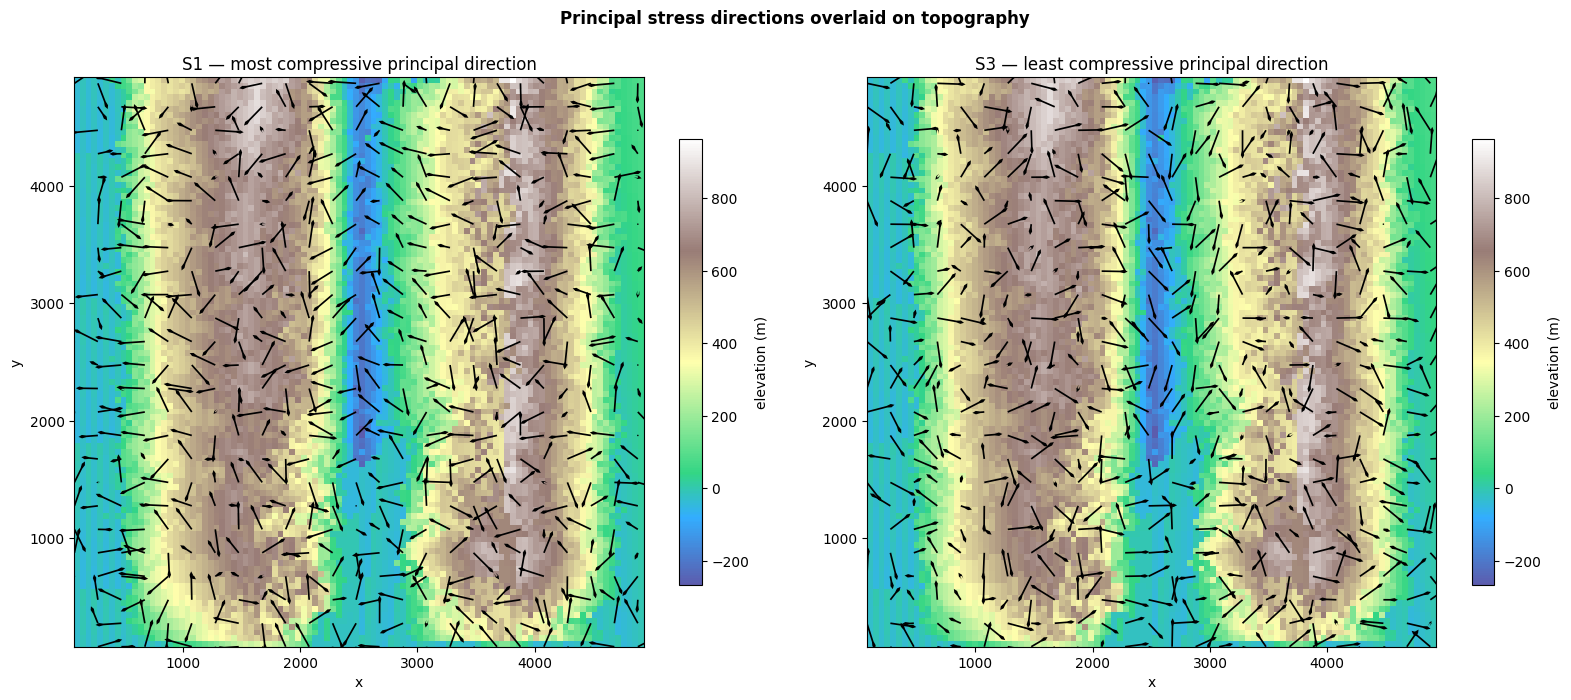

In [14]:
# quiver plot of principal stress directions
# with elevation background

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# S1 -- most compressive
im0 = axes[0].imshow(z_grid, cmap='terrain', origin='lower',
                      extent=[xx.min(), xx.max(), yy.min(), yy.max()],
                      alpha=0.8)
axes[0].quiver(x_q, y_q, S1_x, S1_y,
               color='black', scale=20, width=0.003,
               headwidth=2, headlength=2)
plt.colorbar(im0, ax=axes[0], shrink=0.7, label='elevation (m)')
axes[0].set_title('S1 — most compressive principal direction')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')

# S3 -- least compressive
im1 = axes[1].imshow(z_grid, cmap='terrain', origin='lower',
                      extent=[xx.min(), xx.max(), yy.min(), yy.max()],
                      alpha=0.8)
axes[1].quiver(x_q, y_q, S3_x, S3_y,
               color='black', scale=20, width=0.003,
               headwidth=2, headlength=2)
plt.colorbar(im1, ax=axes[1], shrink=0.7, label='elevation (m)')
axes[1].set_title('S3 — least compressive principal direction')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')

plt.suptitle('Principal stress directions overlaid on topography',
             fontsize=12, fontweight='bold')
plt.tight_layout()
# plt.savefig('principals_z.png')
plt.show()

x indices: 69 to 89, x range: 3528 to 4528
y indices: 34 to 54, y range: 1775 to 2775


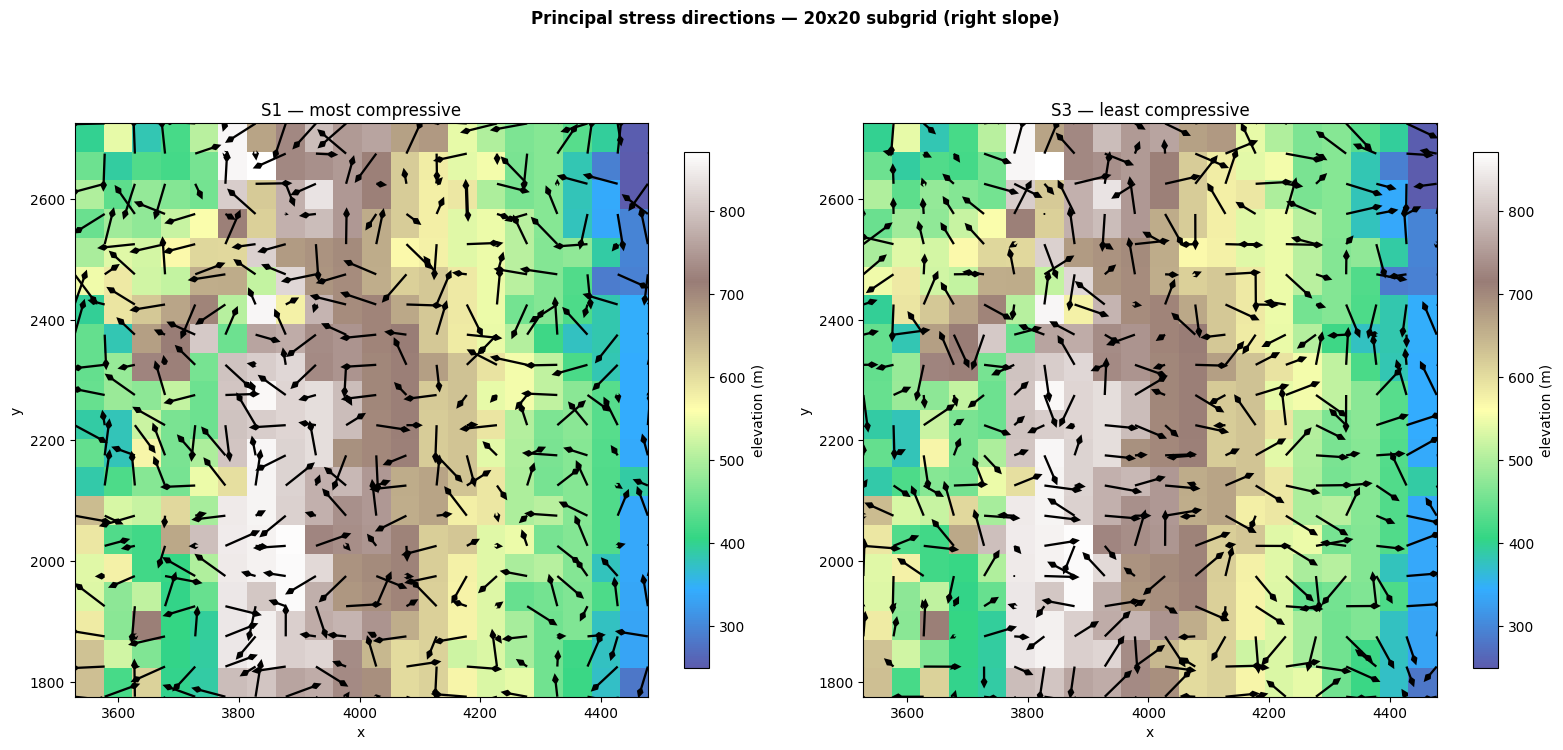

In [15]:
# define 20x20 subgrid -- centered vertically, offset horizontally to avoid glacier
# glacier appears to be around x=2000-3000, so let's sample from the right side
# find index ranges corresponding to roughly x=3500-4500, y=1500-3500

x_lo = np.searchsorted(x_grid, 3500)
x_hi = x_lo + 20
y_lo = np.searchsorted(y_grid, 1750)
y_hi = y_lo + 20

print(f"x indices: {x_lo} to {x_hi}, x range: {x_grid[x_lo]:.0f} to {x_grid[x_hi]:.0f}")
print(f"y indices: {y_lo} to {y_hi}, y range: {y_grid[y_lo]:.0f} to {y_grid[y_hi]:.0f}")

# extract subgrid
sub_xx = xx[y_lo:y_hi, x_lo:x_hi]
sub_yy = yy[y_lo:y_hi, x_lo:x_hi]
sub_z  = z_grid[y_lo:y_hi, x_lo:x_hi]

sub_S1x = Svec_grid[y_lo:y_hi, x_lo:x_hi, 0, 0]
sub_S1y = Svec_grid[y_lo:y_hi, x_lo:x_hi, 0, 1]
sub_S3x = Svec_grid[y_lo:y_hi, x_lo:x_hi, 2, 0]
sub_S3y = Svec_grid[y_lo:y_hi, x_lo:x_hi, 2, 1]

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for ax, Sx, Sy, label in zip(axes,
                              [sub_S1x, sub_S3x],
                              [sub_S1y, sub_S3y],
                              ['S1 — most compressive', 'S3 — least compressive']):
    im = ax.imshow(sub_z, cmap='terrain', origin='lower',
                   extent=[sub_xx.min(), sub_xx.max(),
                            sub_yy.min(), sub_yy.max()],
                   alpha=0.8)
    ax.quiver(sub_xx, sub_yy, Sx, Sy,
              color='black', scale=15, width=0.004,
              headwidth=3, headlength=3)
    plt.colorbar(im, ax=ax, shrink=0.7, label='elevation (m)')
    ax.set_title(label)
    ax.set_xlabel('x')
    ax.set_ylabel('y')

plt.suptitle('Principal stress directions — 20x20 subgrid (right slope)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
# plt.savefig('principals_subgrid.png')
plt.show()

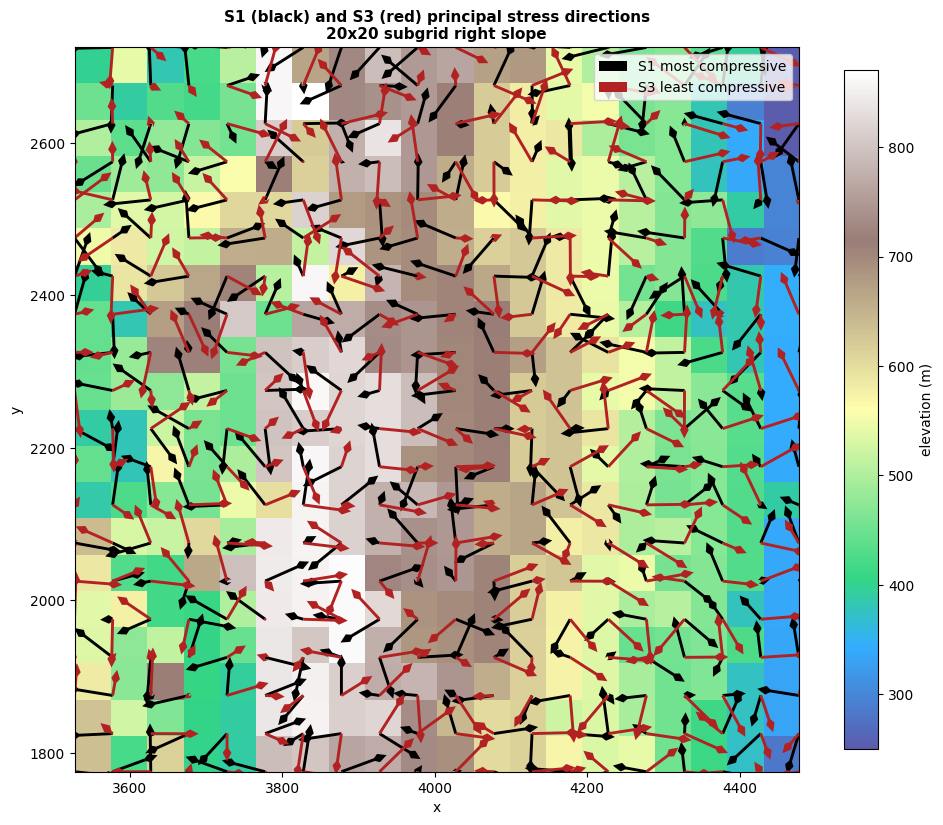

In [16]:
fig, ax = plt.subplots(figsize=(10, 10))

im = ax.imshow(sub_z, cmap='terrain', origin='lower',
               extent=[sub_xx.min(), sub_xx.max(),
                        sub_yy.min(), sub_yy.max()],
               alpha=0.8)

# S1 -- most compressive -- black
ax.quiver(sub_xx, sub_yy, sub_S1x, sub_S1y,
          color='black', scale=15, width=0.004,
          headwidth=3, headlength=3, label='S1 most compressive')

# S3 -- least compressive -- red
ax.quiver(sub_xx, sub_yy, sub_S3x, sub_S3y,
          color='firebrick', scale=15, width=0.004,
          headwidth=3, headlength=3, label='S3 least compressive')

plt.colorbar(im, ax=ax, shrink=0.7, label='elevation (m)')
ax.legend(loc='upper right', fontsize=10)
ax.set_title('S1 (black) and S3 (red) principal stress directions\n20x20 subgrid right slope',
             fontsize=11, fontweight='bold')
ax.set_xlabel('x')
ax.set_ylabel('y')

plt.tight_layout()
# plt.savefig('S1S3_subgrid.png')
plt.show()

In [17]:
# consider graph with the following properties:
# 
# given principal unit vector Si, project onto horizontal
# assuming unit squares, connect only if the projection 
# reaches from origin square center into adjacent square
#
# weight the edge by vector magnitude -- scale by magnitude.max
#
# if two edges overlap, weight by mean(wij, wi'j')
#
# build separate graphs for S1 and S3

In [18]:
# start on subgrid

In [19]:
# use to find vector projection into adjacent grid squares
import math

def round_half_away(x):
    eps = 1e-9
    return int(math.floor(abs(x) + 0.5 + eps) * (1 if x>= 0 else -1))

In [20]:
from collections import defaultdict
# on the 20x20 subgrid
# Svec_grid indices: [row, col, eigenvector, component]
sub_S1 = Svec_grid[y_lo:y_hi, x_lo:x_hi, 0, :] # shape (20,20,3)

h_sub, w_sub = 20, 20

# compute horizontal projection magnitudes for normalization
horiz_mag = np.sqrt(sub_S1[:,:,0]**2 + sub_S1[:,:,1]**2) # sqrt(Sx^2+Sy^2)
max_horiz = horiz_mag.max()
print(f"horizontal projection magnitude range: {horiz_mag.min():.4f} to {horiz_mag.max():.4f}")

# build directed edge list: (i,j) -> weight

edgesS1 = {}

for i in range(h_sub):
    for j in range(w_sub):
        Sx = sub_S1[i, j, 0] # x component
        Sy = sub_S1[i, j, 1] # y component
        Sz = sub_S1[i, j, 2] # z component

        h_mag = math.sqrt(Sx**2 + Sy**2)

        # skip if too vertical -- horiz. mag < 0.5
        if h_mag < 0.5:
            continue

        # find neighbor that projection lands in
        # Sy maps to row (i axis), Sy maps to col (j axis)
        # recall that eigenvectors are normalized
        di = round_half_away(Sy)
        dj = round_half_away(Sx)

        # skip if rounds to the same cell:
        if di == 0 and dj == 0:
            continue

        ni, nj, = i + di, j + dj

        # skip if out of bounds
        if ni < 0 or ni >= h_sub or nj < 0 or nj >= w_sub:
            continue

        weight = h_mag / max_horiz
        edgesS1[(i, j, ni, nj)] = weight

print(f"directed edges: {len(edgesS1)}")

# symmetrize -- for each directed edge, add reverse if not present
# use mean weight for edges that appear in both directions
sym_edgesS1 = {}
for (i, j, ni, nj), w in edgesS1.items():
    key = (min((i,j), (ni,nj)), max((i,j), (ni,nj))) # canonical undirected key
    if key not in sym_edgesS1:
        sym_edgesS1[key] = []
    sym_edgesS1[key].append(w)

# final edge list with mean weights
final_edgesS1 = {k: np.mean(v) for k, v in sym_edgesS1.items()}
print(f"undirected edges after symmetrization: {len(final_edgesS1)}")

# degree per node
degreeS1 = defaultdict(float)
for ((i,j),(ni,nj)), w in final_edgesS1.items():
    degreeS1[(i,j)] += w
    degreeS1[(ni,nj)] += w

degreesS1 = [degreeS1[(i,j)] for i in range(h_sub) for j in range(w_sub)]
print(f"nodes with degree = 0: {sum(d == 0 for d in degreesS1)}")
print(f"nodes with degree > 0: {sum(d > 0 for d in degreesS1)}")
print(f"nodes with degree > 1: {sum(d > 1 for d in degreesS1)}")
print(f"max degree: {max(degreesS1):.4f}")
print(f"mean degree: {np.mean(degreesS1):.4f}")

horizontal projection magnitude range: 0.0677 to 1.0000
directed edges: 283
undirected edges after symmetrization: 273
nodes with degree = 0: 37
nodes with degree > 0: 363
nodes with degree > 1: 146
max degree: 2.9801
mean degree: 1.2169


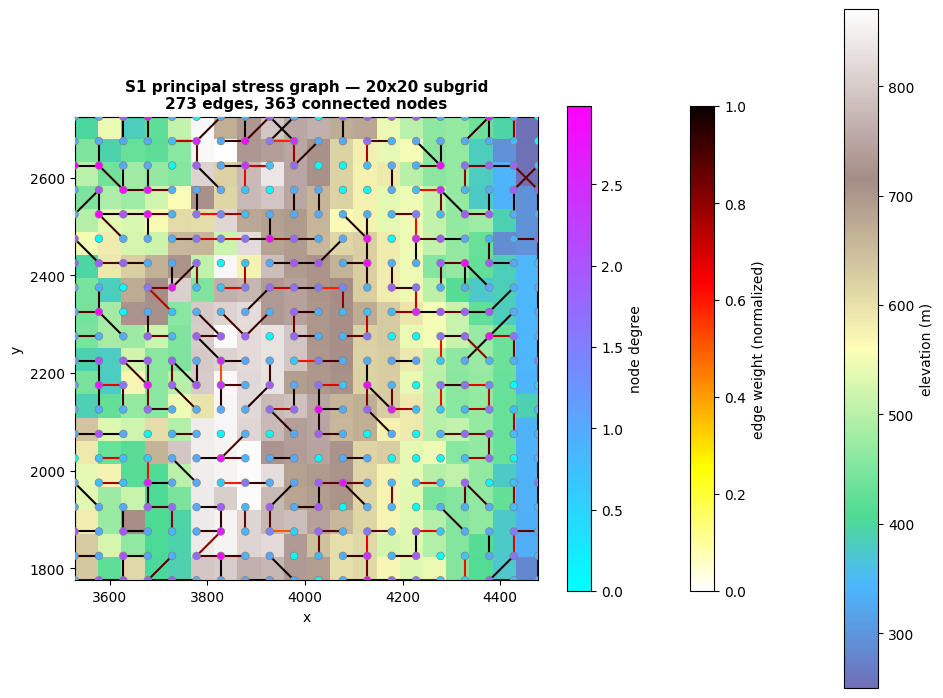

In [21]:
import matplotlib.pyplot as plt
import matplotlib.collections as mc

fig, ax = plt.subplots(figsize=(10, 10))

# background topography
im = ax.imshow(sub_z, cmap='terrain', origin='lower',
               extent=[sub_xx.min(), sub_xx.max(),
                        sub_yy.min(), sub_yy.max()],
               alpha=0.7)
plt.colorbar(im, ax=ax, shrink=0.7, label='elevation (m)')

# draw edges
lines = []
weights = []
for ((i, j), (ni, nj)), w in final_edgesS1.items():
    x0 = sub_xx[i, j]
    y0 = sub_yy[i, j]
    x1 = sub_xx[ni, nj]
    y1 = sub_yy[ni, nj]
    lines.append([(x0, y0), (x1, y1)])
    weights.append(w)

# color edges by weight
lc = mc.LineCollection(lines, array=np.array(weights),
                        cmap='hot_r', linewidths=1.5,
                        zorder=2)
lc.set_clim(0, 1)
ax.add_collection(lc)
plt.colorbar(lc, ax=ax, shrink=0.5, label='edge weight (normalized)')

# draw nodes -- color by degree
node_x = []
node_y = []
node_deg = []
for i in range(h_sub):
    for j in range(w_sub):
        node_x.append(sub_xx[i, j])
        node_y.append(sub_yy[i, j])
        node_deg.append(degreeS1[(i, j)])

sc = ax.scatter(node_x, node_y, c=node_deg, cmap='cool', s=30, zorder=3, edgecolors='gray', linewidths=0.5)
plt.colorbar(sc, ax=ax, shrink=0.5, label='node degree')

ax.set_title('S1 principal stress graph — 20x20 subgrid\n'f'{len(final_edgesS1)} edges, {sum(d>0 for d in degreesS1)} connected nodes',fontsize=11, fontweight='bold')
ax.set_xlabel('x')
ax.set_ylabel('y')
plt.tight_layout()
#plt.savefig('S1graph_subgrid.png')
plt.show()

In [22]:

# build the S3 graph
from collections import defaultdict
# on the 20x20 subgrid
# Svec_grid indices: [row, col, eigenvector, component]
sub_S3 = Svec_grid[y_lo:y_hi, x_lo:x_hi, 2, :] # shape (20,20,3)

h_sub, w_sub = 20, 20

# compute horizontal projection magnitudes for normalization
horiz_mag = np.sqrt(sub_S3[:,:,0]**2 + sub_S3[:,:,1]**2) # sqrt(Sx^2+Sy^2)
max_horiz = horiz_mag.max()
print(f"horizontal projection magnitude range: {horiz_mag.min():.4f} to {horiz_mag.max():.4f}")

# build directed edge list: (i,j) -> weight

edgesS3 = {}

for i in range(h_sub):
    for j in range(w_sub):
        Sx = sub_S3[i, j, 0] # x component
        Sy = sub_S3[i, j, 1] # y component
        Sz = sub_S3[i, j, 2] # z component

        h_mag = math.sqrt(Sx**2 + Sy**2)

        # skip if too vertical -- horiz. mag < 0.5
        if h_mag < 0.5:
            continue

        # find neighbor that projection lands in
        # Sy maps to row (i axis), Sy maps to col (j axis)
        # recall that eigenvectors are normalized
        di = round_half_away(Sy)
        dj = round_half_away(Sx)

        # skip if rounds to the same cell:
        if di == 0 and dj == 0:
            continue

        ni, nj, = i + di, j + dj

        # skip if out of bounds
        if ni < 0 or ni >= h_sub or nj < 0 or nj >= w_sub:
            continue

        weight = h_mag / max_horiz
        edgesS3[(i, j, ni, nj)] = weight

print(f"directed edges: {len(edgesS3)}")

# symmetrize -- for each directed edge, add reverse if not present
# use mean weight for edges that appear in both directions
sym_edgesS3 = {}
for (i, j, ni, nj), w in edgesS3.items():
    key = (min((i,j), (ni,nj)), max((i,j), (ni,nj))) # canonical undirected key
    if key not in sym_edgesS3:
        sym_edgesS3[key] = []
    sym_edgesS3[key].append(w)

# final edge list with mean weights
final_edgesS3 = {k: np.mean(v) for k, v in sym_edgesS3.items()}
print(f"undirected edges after symmetrization: {len(final_edgesS3)}")

# degree per node
degreeS3 = defaultdict(float)
for ((i,j),(ni,nj)), w in final_edgesS3.items():
    degreeS3[(i,j)] += w
    degreeS3[(ni,nj)] += w

degreesS3 = [degreeS3[(i,j)] for i in range(h_sub) for j in range(w_sub)]
print(f"nodes with degree = 0: {sum(d == 0 for d in degreesS3)}")
print(f"nodes with degree > 0: {sum(d > 0 for d in degreesS3)}")
print(f"nodes with degree > 1: {sum(d > 1 for d in degreesS3)}")
print(f"max degree: {max(degreesS3):.4f}")
print(f"mean degree: {np.mean(degreesS3):.4f}")

horizontal projection magnitude range: 0.0078 to 1.0000
directed edges: 261
undirected edges after symmetrization: 247
nodes with degree = 0: 58
nodes with degree > 0: 342
nodes with degree > 1: 124
max degree: 3.9392
mean degree: 1.0842


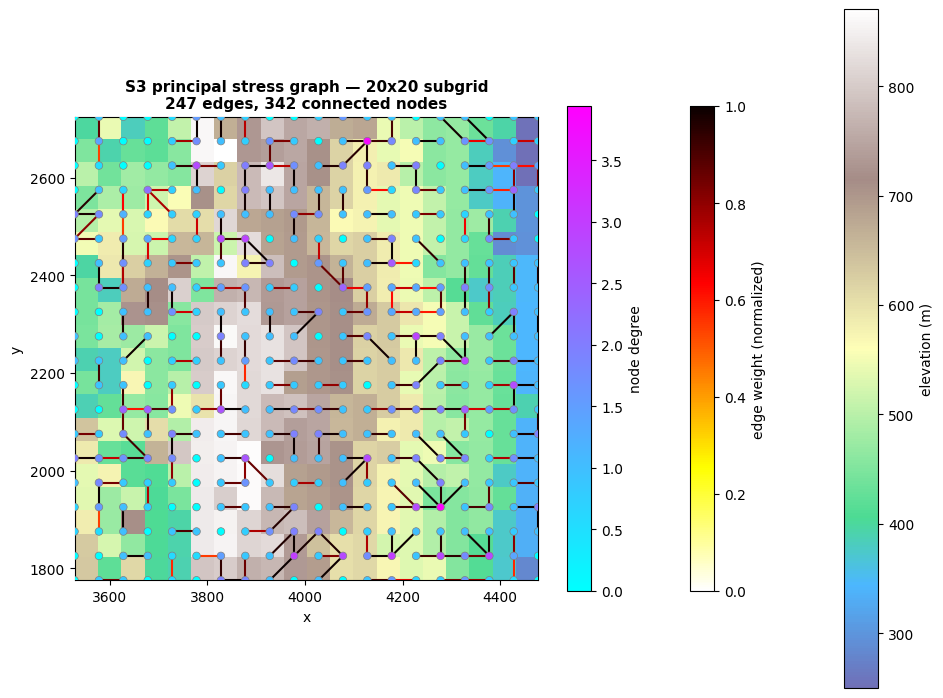

In [23]:
import matplotlib.pyplot as plt
import matplotlib.collections as mc

fig, ax = plt.subplots(figsize=(10, 10))

# background topography
im = ax.imshow(sub_z, cmap='terrain', origin='lower',
               extent=[sub_xx.min(), sub_xx.max(),
                        sub_yy.min(), sub_yy.max()],
               alpha=0.7)
plt.colorbar(im, ax=ax, shrink=0.7, label='elevation (m)')

# draw edges
lines = []
weights = []
for ((i, j), (ni, nj)), w in final_edgesS3.items():
    x0 = sub_xx[i, j]
    y0 = sub_yy[i, j]
    x1 = sub_xx[ni, nj]
    y1 = sub_yy[ni, nj]
    lines.append([(x0, y0), (x1, y1)])
    weights.append(w)

# color edges by weight
lc = mc.LineCollection(lines, array=np.array(weights),
                        cmap='hot_r', linewidths=1.5,
                        zorder=2)
lc.set_clim(0, 1)
ax.add_collection(lc)
plt.colorbar(lc, ax=ax, shrink=0.5, label='edge weight (normalized)')

# draw nodes -- color by degree
node_x = []
node_y = []
node_deg = []
for i in range(h_sub):
    for j in range(w_sub):
        node_x.append(sub_xx[i, j])
        node_y.append(sub_yy[i, j])
        node_deg.append(degreeS3[(i, j)])

sc = ax.scatter(node_x, node_y, c=node_deg, cmap='cool', s=30, zorder=3, edgecolors='gray', linewidths=0.5)
plt.colorbar(sc, ax=ax, shrink=0.5, label='node degree')

ax.set_title('S3 principal stress graph — 20x20 subgrid\n'f'{len(final_edgesS3)} edges, {sum(d>0 for d in degreesS3)} connected nodes',fontsize=11, fontweight='bold')
ax.set_xlabel('x')
ax.set_ylabel('y')
plt.tight_layout()
# plt.savefig('S3graph_subgrid.png')
plt.show()

In [24]:
### build combined graph ###
# connect with all S1 and S3 edges
# but preserve S1 and S3 labels
# for later decomposition

from collections import defaultdict

# combine S1 and S3 edges
# preserve source principal direction as attribute
combined_edges = {} # key: (i, j, ni, nj) -> {'weight':w, 'source': 'S1'|'S3'|'both'}

for key, w in final_edgesS1.items():
    combined_edges[key] = {'weight': w, 'source': 'S1'}

for key, w in final_edgesS3.items():
    if key in combined_edges:
        # overlap -- take max weight, mark as both
        combined_edges[key] = {
            'weight': max(combined_edges[key]['weight'], w),
            'source': 'both'
        }
    else:
        combined_edges[key] = {'weight': w, 'source': 'S3'}

# degree per node
degree_combined = defaultdict(float)
for ((i, j), (ni, nj)), attr in combined_edges.items():
    degree_combined[(i,j)] += attr['weight']
    degree_combined[(ni,nj)] += attr['weight']

degrees_combined = [degree_combined[(i,j)] for i in range(h_sub) for j in range(w_sub)]

n_isolated = sum(d == 0 for d in degrees_combined)
n_s1_only = sum(1 for attr in combined_edges.values() if attr['source'] == 'S1')
n_s3_only = sum(1 for attr in combined_edges.values() if attr['source'] == 'S3')
n_both    = sum(1 for attr in combined_edges.values() if attr['source'] == 'both')

print(f"combined edges total: {len(combined_edges)}")
print(f"     S1 only:    {n_s1_only}")
print(f"     S3 only:    {n_s3_only}")
print(f"     overlap:    {n_both}")
print(f"nodes isolated in combined: {n_isolated}")
print(f"nodes with degree > 0: {sum(d > 0 for d in degrees_combined)}")
print(f"nodes with degree > 1: {sum(d > 1 for d in degrees_combined)}")
print(f"max degree: {max(degrees_combined):.4f}")
print(f"mean degree: {np.mean(degrees_combined):.4f}")

combined edges total: 462
     S1 only:    215
     S3 only:    189
     overlap:    58
nodes isolated in combined: 0
nodes with degree > 0: 400
nodes with degree > 1: 325
max degree: 4.8817
mean degree: 2.0721


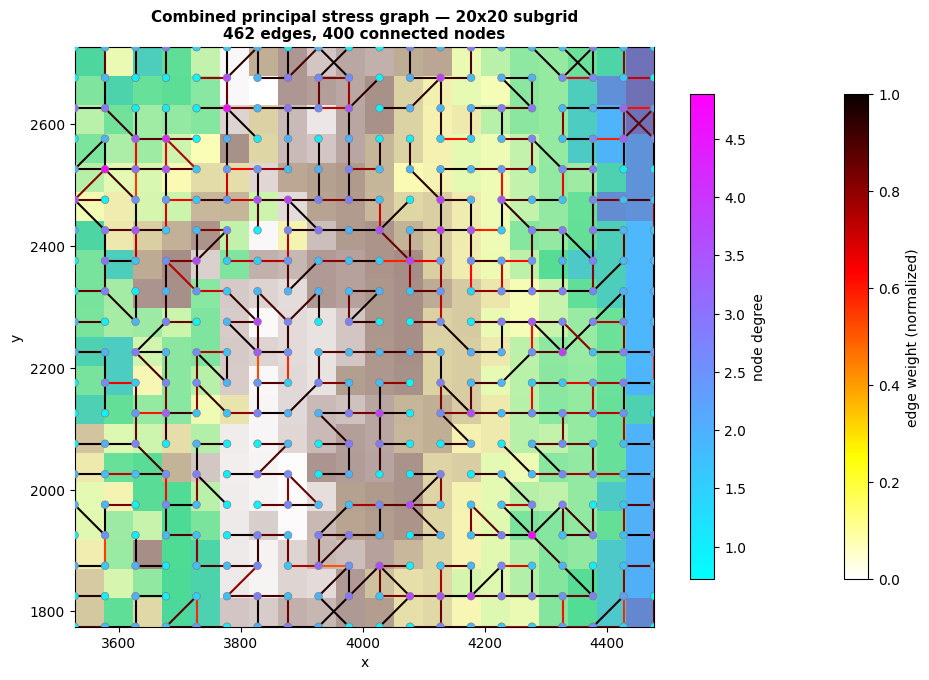

In [25]:
import matplotlib.pyplot as plt
import matplotlib.collections as mc

fig, ax = plt.subplots(figsize=(10, 10))

# background topography
im = ax.imshow(sub_z, cmap='terrain', origin='lower',
               extent=[sub_xx.min(), sub_xx.max(),
                        sub_yy.min(), sub_yy.max()],
               alpha=0.7)
#plt.colorbar(im, ax=ax, shrink=0.7, label='elevation (m)')

# draw edges
lines = []
weights = []
for ((i, j), (ni, nj)), attr in combined_edges.items():
    x0 = sub_xx[i, j]
    y0 = sub_yy[i, j]
    x1 = sub_xx[ni, nj]
    y1 = sub_yy[ni, nj]
    lines.append([(x0, y0), (x1, y1)])
    weights.append(attr['weight'])

# color edges by weight
lc = mc.LineCollection(lines, array=np.array(weights),
                        cmap='hot_r', linewidths=1.5,
                        zorder=2)
lc.set_clim(0, 1)
ax.add_collection(lc)
plt.colorbar(lc, ax=ax, shrink=0.5, label='edge weight (normalized)')

# draw nodes -- color by degree
node_x = []
node_y = []
node_deg = []
for i in range(h_sub):
    for j in range(w_sub):
        node_x.append(sub_xx[i, j])
        node_y.append(sub_yy[i, j])
        node_deg.append(degree_combined[(i, j)])

sc = ax.scatter(node_x, node_y, c=node_deg, cmap='cool', s=30, zorder=3, edgecolors='gray', linewidths=0.5)
plt.colorbar(sc, ax=ax, shrink=0.5, label='node degree')

ax.set_title('Combined principal stress graph — 20x20 subgrid\n'f'{len(combined_edges)} edges, {sum(d>0 for d in degrees_combined)} connected nodes',fontsize=11, fontweight='bold')
ax.set_xlabel('x')
ax.set_ylabel('y')
plt.tight_layout()
plt.savefig('S1S3graph_subgrid.png')
plt.show()

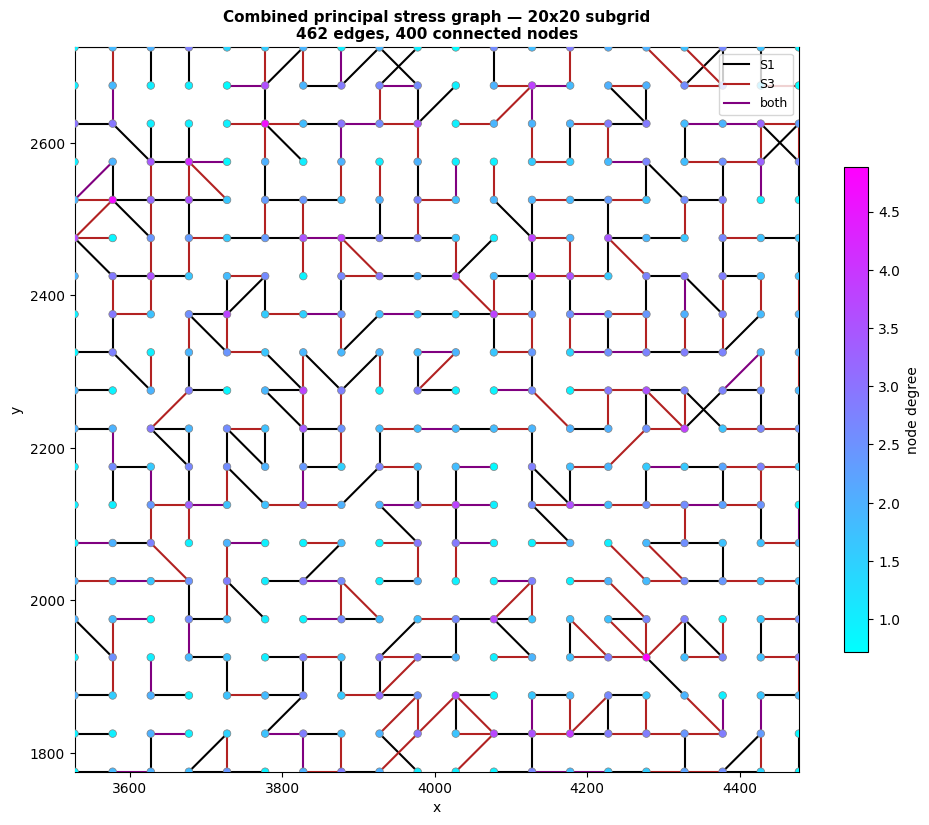

In [26]:
fig, ax = plt.subplots(figsize=(10, 10))

# draw edges
lines = []
weights = []
colors = []
for ((i, j), (ni, nj)), attr in combined_edges.items():
    x0, y0 = sub_xx[i, j], sub_yy[i, j]
    x1, y1 = sub_xx[ni, nj], sub_yy[ni, nj]
    lines.append([(x0, y0), (x1, y1)])
    weights.append(attr['weight'])
    colors.append({'S1': 'black', 'S3': 'firebrick', 'both': 'purple'}[attr['source']])

lc = mc.LineCollection(lines, colors=colors, linewidths=1.5, zorder=2)
ax.add_collection(lc)

# nodes
sc = ax.scatter(node_x, node_y, c=degrees_combined, cmap='cool',
    s=30, zorder=3, edgecolors='gray', linewidths=0.5)
plt.colorbar(sc, ax=ax, shrink=0.5, label='node degree')

# set axis limits explicitly
ax.set_xlim(sub_xx.min(), sub_xx.max())
ax.set_ylim(sub_yy.min(), sub_yy.max())

# legend for edge source
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='black', label='S1'),
    Line2D([0], [0], color='firebrick', label='S3'),
    Line2D([0], [0], color='purple', label='both')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=9)

ax.set_title('Combined principal stress graph — 20x20 subgrid\n'
             f'{len(combined_edges)} edges, {sum(d>0 for d in degrees_combined)} connected nodes',
             fontsize=11, fontweight='bold')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_aspect('equal')
plt.tight_layout()
# plt.savefig('S1S3graph_subgrid_noterrain.png')
plt.show()

In [27]:
# no isolated nodes but check for multiple connected components

import networkx as nx

G = nx.Graph()
for ((i,j), (ni,nj)), attr in combined_edges.items():
    G.add_edge((i,j), (ni,nj), weight=attr['weight'], source=attr['source'])

n_components = nx.number_connected_components(G)
component_sizes = sorted([len(c) for c in nx.connected_components(G)], reverse=True)
print(f"connected components: {n_components}")
print(f"component sizes: {component_sizes}")

connected components: 10
component sizes: [366, 8, 5, 4, 4, 4, 3, 2, 2, 2]


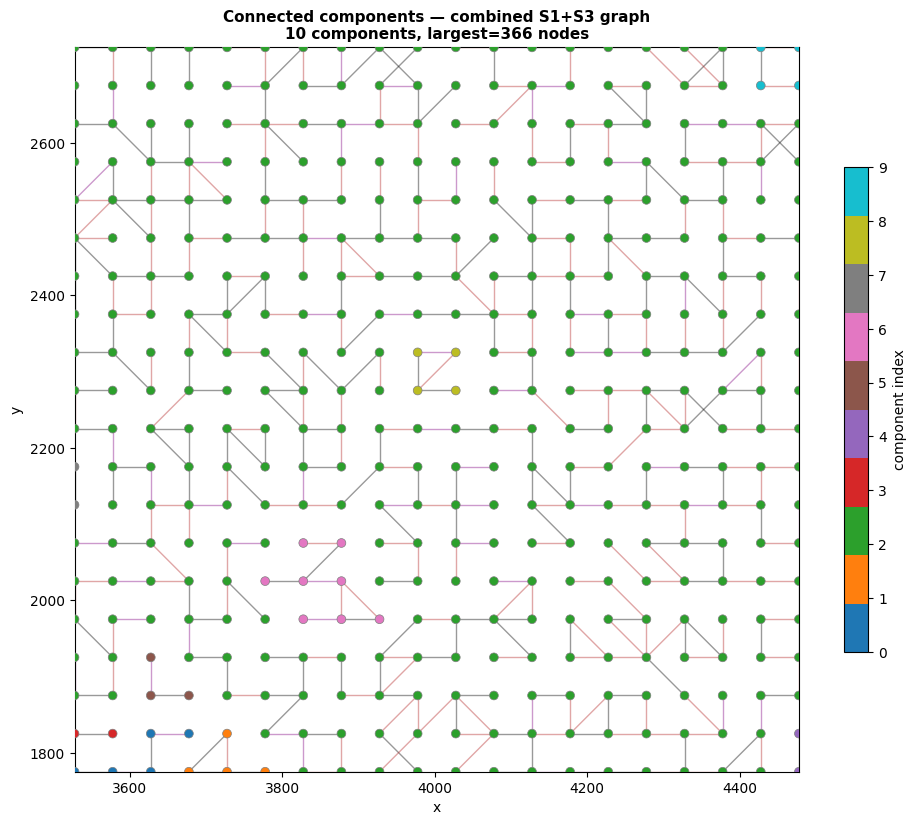

In [28]:
fig, ax = plt.subplots(figsize=(10, 10))

# color nodes by component
component_map = {}
for idx, component in enumerate(nx.connected_components(G)):
    for node in component:
        component_map[node] = idx

node_comp = [component_map.get((i,j), -1) 
             for i in range(h_sub) for j in range(w_sub)]

# draw edges
lines = []
colors = []
for ((i, j), (ni, nj)), attr in combined_edges.items():
    lines.append([(sub_xx[i,j], sub_yy[i,j]), 
                  (sub_xx[ni,nj], sub_yy[ni,nj])])
    colors.append({'S1':'black','S3':'firebrick','both':'purple'}[attr['source']])

lc = mc.LineCollection(lines, colors=colors, linewidths=1.0, zorder=2, alpha=0.4)
ax.add_collection(lc)

sc = ax.scatter(node_x, node_y, c=node_comp, cmap='tab10',
    s=40, zorder=3, edgecolors='gray', linewidths=0.5)
plt.colorbar(sc, ax=ax, shrink=0.5, label='component index')

ax.set_xlim(sub_xx.min(), sub_xx.max())
ax.set_ylim(sub_yy.min(), sub_yy.max())
ax.set_aspect('equal')
ax.set_title('Connected components — combined S1+S3 graph\n'
             f'10 components, largest={366} nodes',
             fontsize=11, fontweight='bold')
ax.set_xlabel('x')
ax.set_ylabel('y')
plt.tight_layout()
plt.show()

In [29]:
### prepare for graph entropy calculation ###

In [30]:
### build weighted adjacency matrix ###

import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla

n_nodes = h_sub * w_sub # 400

# node index mapping: (i,j) --> flat index
def node_idx(i, j, ncols=w_sub):
    return i * ncols + j

# build sparse weight matrix
rows, cols, weights = [], [], []

for ((i,j),(ni,nj)), attr in combined_edges.items():
    u = node_idx(i,j)
    v = node_idx(ni,nj)
    w = attr['weight']
    # undirected -- add both directions
    rows += [u,v]
    cols += [v,u]
    weights += [w,w]

W = sp.csr_matrix((weights, (rows, cols)), shape=(n_nodes, n_nodes))
print("adj. matrix complete")

adj. matrix complete


In [31]:
### degree matrix ###
d = np.array(W.sum(axis=1)).flatten()
print(f"degree vector range: {d.min():.4f} to {d.max():.4f}")
print(f"zero-degree nodes: {(d==0).sum()}")

degree vector range: 0.7181 to 4.8817
zero-degree nodes: 0


In [32]:
# normalized laplacian: L = D^(-1/2) (D-W) D^(-1/2)
# for isolated nodes (d==0), set d^(-1/2) = 0
d_inv_sqrt = np.where(d > 0, 1.0/np.sqrt(d), 0.0)
D_inv_sqrt = sp.diags(d_inv_sqrt)

L = sp.eye(n_nodes) - D_inv_sqrt @ W @ D_inv_sqrt

print(f"Laplacian shape: {L.shape}")
print(f"Laplacian density: {L.nnz / n_nodes**2:.4f}")

Laplacian shape: (400, 400)
Laplacian density: 0.0083


In [33]:
## laplacian is very sparse -- good for eigenvalue calculations

In [34]:
## compute all eigenvalues of the normalized laplacian
# for a 400x400 matrix, full dense eigendecomposition is fine
eigenvalues = np.linalg.eigvalsh(L.toarray())

print(f"eigenvalue range: {eigenvalues.min():.6f} to {eigenvalues.max():.6f}")
print(f"near-zero eigenvalues (< 1e-10): {(np.abs(eigenvalues) < 1e-10).sum()}")
print(f"negative eigenvalues: {(eigenvalues < -1e-10).sum()}")

eigenvalue range: -0.000000 to 2.000000
near-zero eigenvalues (< 1e-10): 10
negative eigenvalues: 0


In [35]:
# clip small negatives (arising from floating point noise)
eigenvalues = np.clip(eigenvalues, 0, None)
print("clipped")

clipped


In [36]:
# von Neumann entropy
# p_i = lambda_i / sum(lambda_i)
# S = -sum(p_i * log(p_i)); 0*log(0) = 0 by convention
lambda_sum = eigenvalues.sum()
print(f"\nsum of eigenvalues: {lambda_sum:.6f}")

p = eigenvalues / lambda_sum
# mask zeros to avoid log(0)
nonzero = p > 0
S = -np.sum(p[nonzero] * np.log(p[nonzero]))

print(f"von Neumann entropy: {S:.6f}")
print(f"max possible entropy (log n): {np.log(n_nodes):.6f}")
print(f"normalized entropy (S / log n): {S / np.log(n_nodes):.6f}")


sum of eigenvalues: 400.000000
von Neumann entropy: 5.721436
max possible entropy (log n): 5.991465
normalized entropy (S / log n): 0.954931


In [37]:
# visualize Fiedler (2nd) eigenvector

# compute eigenvalues and eigenvectors of the normalized laplacian
eigenvalues, eigenvectors = np.linalg.eigh(L.toarray())

# second eigenvector -- index 1 after sorting ascending
fiedler = eigenvectors[:, 10] # shape (n_nodes, )

print(f"second nonzero eigenvalue (\"Fiedler\" value): {eigenvalues[10]:.6f}")
print(f"fiedler vector range: {fiedler.min():4f} to {fiedler.max():.4f}")

second nonzero eigenvalue ("Fiedler" value): 0.000777
fiedler vector range: -0.140801 to 0.0930


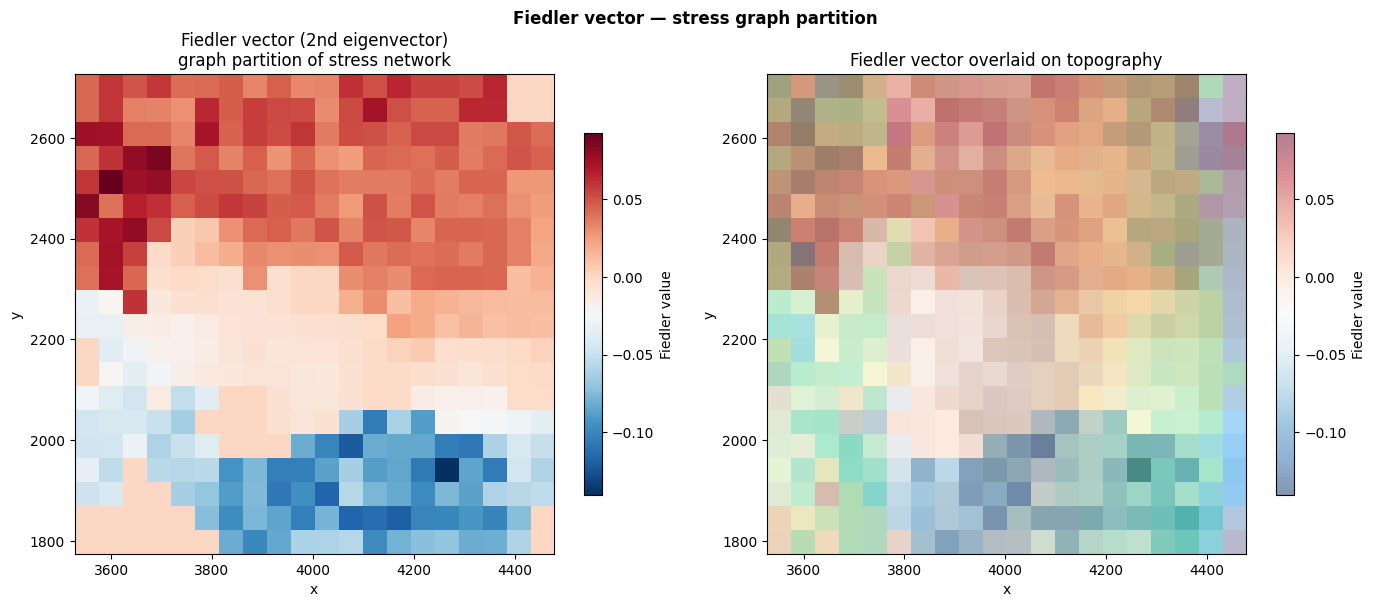

In [38]:
# "Fiedler" plot continued

# reshape to spatial grid
fiedler_grid = fiedler.reshape(h_sub, w_sub)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# fiedler vector as spatial map
im0 = axes[0].imshow(fiedler_grid, cmap='RdBu_r', origin='lower',
                      extent=[sub_xx.min(), sub_xx.max(),
                               sub_yy.min(), sub_yy.max()])
plt.colorbar(im0, ax=axes[0], shrink=0.7, label='Fiedler value')
axes[0].set_title('Fiedler vector (2nd eigenvector)\ngraph partition of stress network')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')

# overlay on topography
im1 = axes[1].imshow(sub_z, cmap='terrain', origin='lower',
                      extent=[sub_xx.min(), sub_xx.max(),
                               sub_yy.min(), sub_yy.max()],
                      alpha=0.6)
im2 = axes[1].imshow(fiedler_grid, cmap='RdBu_r', origin='lower',
                      extent=[sub_xx.min(), sub_xx.max(),
                               sub_yy.min(), sub_yy.max()],
                      alpha=0.5)
plt.colorbar(im2, ax=axes[1], shrink=0.7, label='Fiedler value')
axes[1].set_title('Fiedler vector overlaid on topography')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')

plt.suptitle('Fiedler vector — stress graph partition', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

x indices: 69 to 89, x range: 3528 to 4528
y indices: 34 to 54, y range: 1775 to 2775


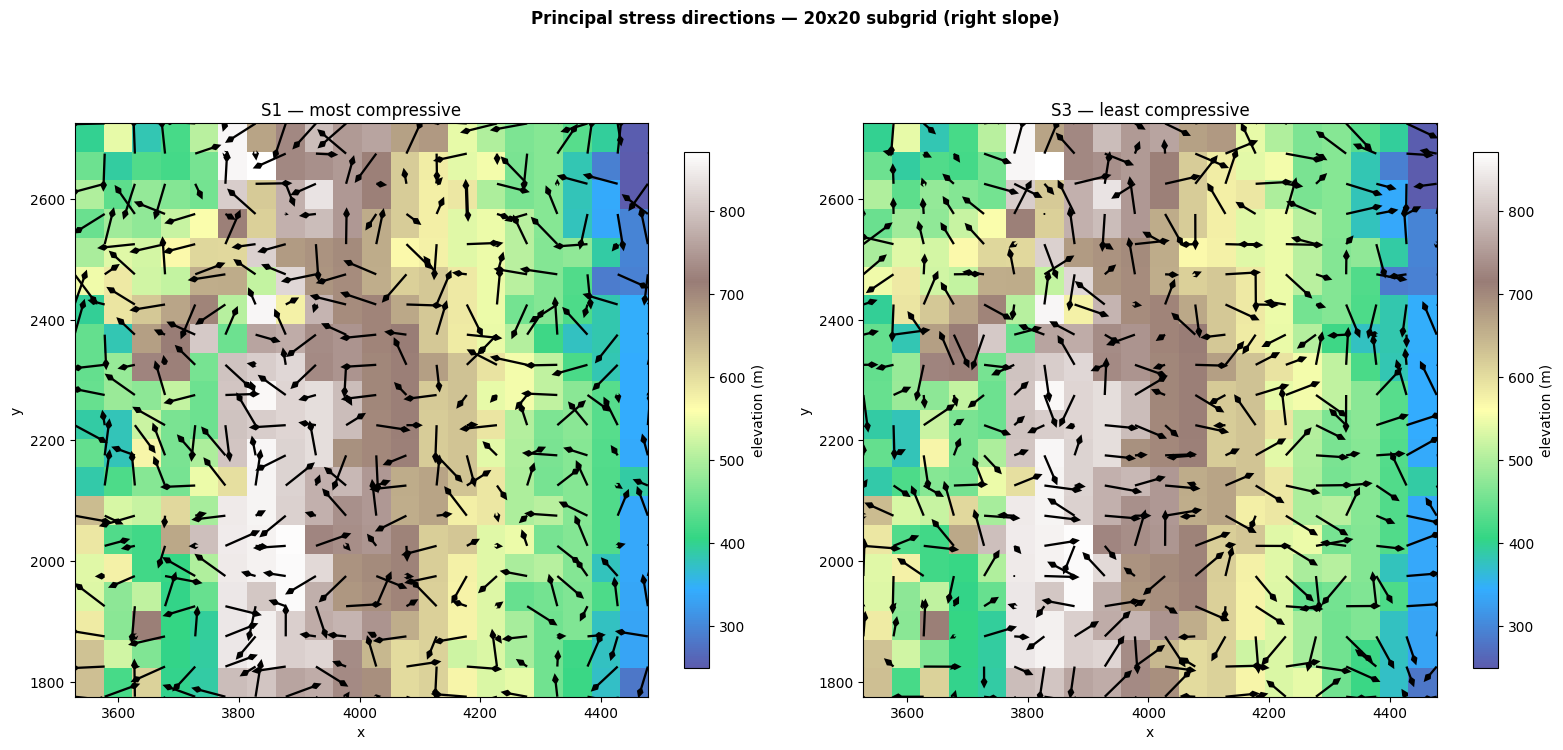

In [39]:
# define 20x20 subgrid -- centered vertically, offset horizontally to avoid glacier
# glacier appears to be around x=2000-3000, so let's sample from the right side
# find index ranges corresponding to roughly x=3500-4500, y=1500-3500

x_lo = np.searchsorted(x_grid, 3500)
x_hi = x_lo + 20
y_lo = np.searchsorted(y_grid, 1750)
y_hi = y_lo + 20

print(f"x indices: {x_lo} to {x_hi}, x range: {x_grid[x_lo]:.0f} to {x_grid[x_hi]:.0f}")
print(f"y indices: {y_lo} to {y_hi}, y range: {y_grid[y_lo]:.0f} to {y_grid[y_hi]:.0f}")

# extract subgrid
sub_xx = xx[y_lo:y_hi, x_lo:x_hi]
sub_yy = yy[y_lo:y_hi, x_lo:x_hi]
sub_z  = z_grid[y_lo:y_hi, x_lo:x_hi]

sub_S1x = Svec_grid[y_lo:y_hi, x_lo:x_hi, 0, 0]
sub_S1y = Svec_grid[y_lo:y_hi, x_lo:x_hi, 0, 1]
sub_S3x = Svec_grid[y_lo:y_hi, x_lo:x_hi, 2, 0]
sub_S3y = Svec_grid[y_lo:y_hi, x_lo:x_hi, 2, 1]

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for ax, Sx, Sy, label in zip(axes,
                              [sub_S1x, sub_S3x],
                              [sub_S1y, sub_S3y],
                              ['S1 — most compressive', 'S3 — least compressive']):
    im = ax.imshow(sub_z, cmap='terrain', origin='lower',
                   extent=[sub_xx.min(), sub_xx.max(),
                            sub_yy.min(), sub_yy.max()],
                   alpha=0.8)
    ax.quiver(sub_xx, sub_yy, Sx, Sy,
              color='black', scale=15, width=0.004,
              headwidth=3, headlength=3)
    plt.colorbar(im, ax=ax, shrink=0.7, label='elevation (m)')
    ax.set_title(label)
    ax.set_xlabel('x')
    ax.set_ylabel('y')

plt.suptitle('Principal stress directions — 20x20 subgrid (right slope)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
# plt.savefig('principals_subgrid.png')
plt.show()